# M4.Ex1: Housing Prices Model (PyCaret)

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M6/exercises/ex1_pycaret_regression.ipynb)

## Exercise

Your task is to follow the steps outlined here, and apply them on the **California Housing Dataset** below:

- [**🚀 Regression**](https://pycaret.gitbook.io/docs/get-started/quickstart#regression)
    - Setup
    - Compare Models
    - Analyze Model
    - Predictions
    - Save the model

## California Housing Prices Dataset


Find and download the dataset from Kaggle at [California Housing Dataset](https://www.kaggle.com/datasets/dhirajnirne/california-housing-data).

According to [keras.io](https://keras.io/api/datasets/california_housing/):

> This dataset was obtained from the StatLib repository.
>
> It's a continuous regression dataset with 20,640 samples with 8 features each.
>
> The target variable is a scalar: the median house value for California districts, in dollars.
>
> The 8 input features are the following:
>
> - MedInc: median income in block group
> - HouseAge: median house age in block group
> - AveRooms: average number of rooms per household
> - AveBedrms: average number of bedrooms per household
> - Population: block group population
> - AveOccup: average number of household members
> - Latitude: block group latitude
> - Longitude: block group longitude
>
> This dataset was derived from the 1990 U.S. census, using one row per census block group. A block group is the smallest geographical unit for which the U.S. Census Bureau publishes sample data (a block group typically has a population of 600 to 3,000 people).
>
> A household is a group of people residing within a home. Since the average number of rooms and bedrooms in this dataset are provided per household, these columns may take surprisingly large values for block groups with few households and many empty houses, such as vacation resorts.

### Load the data

In [2]:
import pandas as pd

housing = pd.read_csv("housing.csv")
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


**Task**: Your model should learn from this data and be able to predict the median housing price (`median_house_value`) in any district, given all the other metrics.

Please read the above dataset description to understand what the features mean.

In [3]:
import pycaret
from pycaret.regression import *

regression_experiment = setup(
    data=housing,
    target="median_house_value",
    session_id=42,
)

best_model = compare_models()
leaderboard = pull()
leaderboard.head()

,Description,Value
0,Session id,42
1,Target,median_house_value
2,Target type,Regression
3,Original data shape,"(20640, 10)"
4,Transformed data shape,"(20640, 14)"
5,Transformed train set shape,"(14447, 14)"
6,Transformed test set shape,"(6193, 14)"
7,Numeric features,8
8,Categorical features,1
9,Rows with missing values,1.0%


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,32615.5586,2495343018.3390,49894.2904,0.8133,0.2405,0.1812,1.6330
et,Extra Trees Regressor,35232.7000,2786953364.2542,52752.5024,0.7916,0.2516,0.1949,0.8970
gbr,Gradient Boosting Regressor,38602.2939,3082713407.7231,55483.0765,0.7696,0.2708,0.2163,0.4640
lr,Linear Regression,49806.7126,4766430820.2192,68985.9241,0.6438,0.3815,0.2861,1.5050
lasso,Lasso Regression,49807.0553,4766438155.7287,68985.9544,0.6438,0.3815,0.2861,0.6120
ridge,Ridge Regression,49807.6436,4766350329.2894,68985.1090,0.6438,0.3817,0.2861,0.0420
llar,Lasso Least Angle Regression,49807.0292,4766437181.7887,68985.9470,0.6438,0.3815,0.2861,0.0500
br,Bayesian Ridge,49818.3722,4768562906.3845,69000.3846,0.6436,0.3818,0.2862,0.0490
lar,Least Angle Regression,49725.7294,4805951256.7804,69270.7307,0.6407,0.3947,0.2837,0.0560
dt,Decision Tree Regressor,44734.5465,4914932063.2055,70053.1791,0.6325,0.3286,0.2436,0.0640


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,32615.5586,2.495343e+09,49894.2904,0.8133,0.2405,0.1812,1.633
et,Extra Trees Regressor,35232.7000,2.786953e+09,52752.5024,0.7916,0.2516,0.1949,0.897
gbr,Gradient Boosting Regressor,38602.2939,3.082713e+09,55483.0765,0.7696,0.2708,0.2163,0.464
lr,Linear Regression,49806.7126,4.766431e+09,68985.9241,0.6438,0.3815,0.2861,1.505
lasso,Lasso Regression,49807.0553,4.766438e+09,68985.9544,0.6438,0.3815,0.2861,0.612


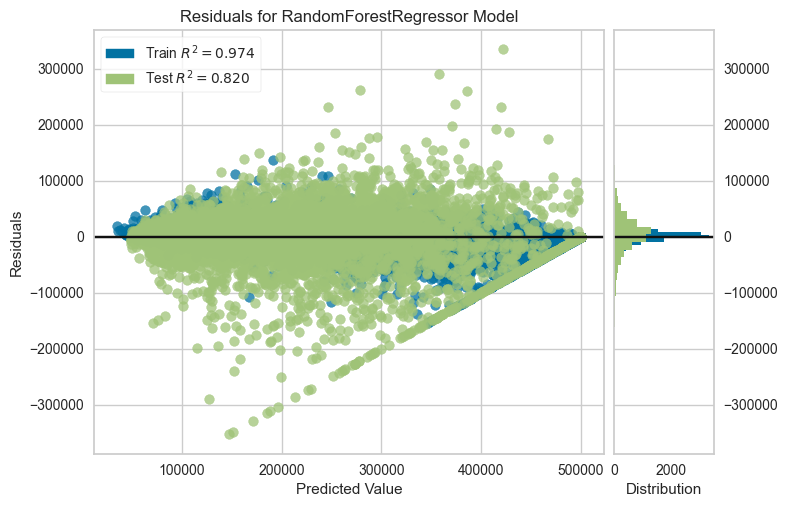

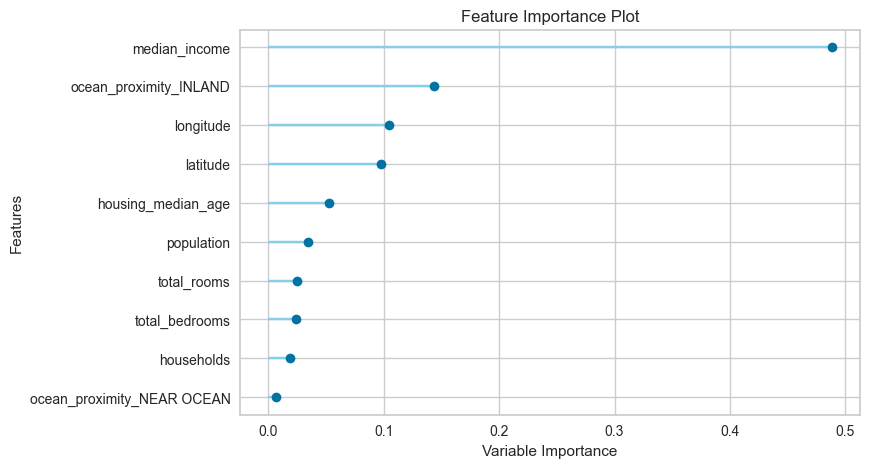

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,31837.7705,2365269521.3707,48634.0367,0.8198,0.2357,0.1787


,median_house_value,prediction_label
20046,47700.0,54040.00
3024,45800.0,67125.00
15663,500001.0,468599.49
20484,218600.0,253231.00
9814,278000.0,271721.00


In [4]:
plot_model(best_model, plot="residuals")
plot_model(best_model, plot="feature")

holdout_predictions = predict_model(best_model)
holdout_predictions[["median_house_value", "prediction_label"]].head()

In [5]:
new_data = housing.drop(columns=["median_house_value"]).sample(5, random_state=42)
new_predictions = predict_model(best_model, data=new_data)

save_model(best_model, "california_housing_pycaret_model")
new_predictions

Transformation Pipeline and Model Successfully Saved


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,prediction_label
20046,-119.010002,36.060001,25.0,1505.0,NaN,1392.0,359.0,1.6812,INLAND,54040.00
3024,-119.459999,35.139999,30.0,2943.0,NaN,1565.0,584.0,2.5313,INLAND,67125.00
15663,-122.440002,37.799999,52.0,3830.0,NaN,1310.0,963.0,3.4801,NEAR BAY,468599.49
20484,-118.720001,34.279999,17.0,3051.0,NaN,1705.0,495.0,5.7376,<1H OCEAN,253231.00
9814,-121.930000,36.619999,34.0,2351.0,NaN,1063.0,428.0,3.7250,NEAR OCEAN,271721.00
